# 01 · EDA — Demanda eléctrica del MEM

**Proyecto:** Forecast de demanda eléctrica del Mercado Eléctrico Mayorista (MEM) argentino.

**Etapa:** Pre-entrega 2 — Análisis Exploratorio de Datos (EDA) con Pandas y visualizaciones estadísticas.

## Objetivo de este notebook

Antes de modelar hay que conocer el dato. Acá respondemos:

1. **Volumen y granularidad:** ¿cuántas filas, qué período, cada cuánto tiempo hay una medición?
2. **Calidad:** ¿hay huecos en la serie, duplicados, faltantes, ceros o valores imposibles?
3. **Estructura temporal:** ¿cómo es la curva diaria, semanal y anual? Esto es lo que después el modelo tiene que aprender.
4. **Clima:** ¿cómo se relaciona la demanda con la temperatura, y qué variables climáticas son confiables?

## Datasets

Trabajamos con dos datasets que se complementan:

| Dataset | Granularidad | Período | Rol |
|---|---|---|---|
| `demanda_horaria_mem.csv` | Horaria, total país | 2021-01 → 2026-07 | **Variable objetivo** del modelo |
| `dataset_demanda_por_region.csv` | Diaria, 9 regiones + clima | 2017-01 → 2026-06 | **EDA regional** y relación demanda–temperatura |

**Serie horaria (objetivo).** Sale de dos planillas oficiales de CAMMESA ("Demanda Horaria por Tipo" y "Planilla Demanda Horaria por Regiones"), que coinciden hora a hora en 2023 (diferencia máxima 0,04 %) y se encadenan en una sola serie. Las descarga y las arma el script `src/descargar_demanda_mem.py`.

**Dataset regional diario con clima.** Lo arma el script `src/construir_dataset_regional.py`, combinando la base de demanda diaria por región de CAMMESA con los datos meteorológicos diarios del Servicio Meteorológico Nacional (SMN), tomando una estación representativa seleccionada por región como proxy de su clima. Fuentes:
- https://cammesaweb.cammesa.com/2026/09/18/covid-19-comportamiento-de-la-demanda-de-energia-electrica-en-el-mem/
- https://ws2.smn.gob.ar/descarga-de-datos

**Este dataset diario se usa para el EDA regional, no como variable de entrada del modelo horario.** El futuro modelo va a necesitar temperatura **horaria**: repetir la `TMEDIA` del día en las 24 horas perdería justamente la variación dentro del día (la tarde calurosa, la madrugada fría), que es la que mueve la curva de carga.

**Por qué el objetivo es la serie horaria y no la diaria:** el proyecto promete pronosticar la demanda **hora por hora** para las próximas 24 h, que es lo que CAMMESA necesita para programar el despacho. Con un dato por día no se puede predecir la curva del día ni hacer el clustering de curvas diarias previsto para la etapa no supervisada.

**Unidad:** MWh por hora. Como el intervalo es de una hora, coincide numéricamente con la potencia media en MW de esa hora.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# seteo el tema de sns
sns.set_theme(style="whitegrid", context="notebook")
# calidad de las imágenes en 110 dpi
plt.rcParams["figure.dpi"] = 110

# armo las rutas que voy a utilizar
BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = BASE / "data" / "processed"
FIG = BASE / "reports" / "figures"

# creo la carpeta donde se guardarán las figuras
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
def guardar(nombre):
    """Muestra el gráfico actual y lo guarda en reports/figures."""
    plt.tight_layout()
    plt.savefig(FIG / f"01_{nombre}.png", bbox_inches="tight")
    plt.show()

# Parte A — Serie horaria del MEM (variable objetivo)

## 1. Carga e inspección inicial

In [3]:
# cargo la serie horaria; parse_dates convierte la columna a datetime al leer
df = pd.read_csv(DATA / "demanda_horaria_mem.csv", parse_dates=["timestamp"])

# veo las primeras filas del dataset para una inspección inicial
df.head()

,timestamp,demanda_mwh,demanda_dist_mwh,demanda_gu_mwh,tipo_dia,fuente
0,2021-01-01 00:00:00,12329.594,NaN,NaN,no_habil,regiones_2021_2023
1,2021-01-01 01:00:00,12097.918,NaN,NaN,no_habil,regiones_2021_2023
2,2021-01-01 02:00:00,11805.739,NaN,NaN,no_habil,regiones_2021_2023
3,2021-01-01 03:00:00,11447.416,NaN,NaN,no_habil,regiones_2021_2023
4,2021-01-01 04:00:00,11143.879,NaN,NaN,no_habil,regiones_2021_2023


In [4]:
# reviso las últimas filas continuando con la inspección inicial
df.tail()

,timestamp,demanda_mwh,demanda_dist_mwh,demanda_gu_mwh,tipo_dia,fuente
48907,2026-07-31 19:00:00,17907.209,15512.087,2395.122,habil,por_tipo_2023_2026
48908,2026-07-31 20:00:00,17980.284,15562.412,2417.872,habil,por_tipo_2023_2026
48909,2026-07-31 21:00:00,17355.938,15037.292,2318.646,habil,por_tipo_2023_2026
48910,2026-07-31 22:00:00,16437.012,14121.070,2315.942,habil,por_tipo_2023_2026
48911,2026-07-31 23:00:00,15428.224,13103.151,2325.073,habil,por_tipo_2023_2026


In [5]:
# veo cantidad de filas y de columnas del dataset
df.shape

(48912, 6)

In [6]:
# veo las columnas del dataset
df.columns

Index(['timestamp', 'demanda_mwh', 'demanda_dist_mwh', 'demanda_gu_mwh',
       'tipo_dia', 'fuente'],
      dtype='str')

In [7]:
# veo los tipos de datos de cada columna del dataset
df.dtypes

timestamp           datetime64[us]
demanda_mwh                float64
demanda_dist_mwh           float64
demanda_gu_mwh             float64
tipo_dia                       str
fuente                         str
dtype: object

In [8]:
# veo cantidad de nulos del dataset
df.isnull().sum()

timestamp               0
demanda_mwh             0
demanda_dist_mwh    17520
demanda_gu_mwh      17520
tipo_dia                0
fuente                  0
dtype: int64

In [9]:
# veo si el dataset tiene filas duplicadas
df.duplicated().sum()

np.int64(0)

In [10]:
# veo un resumen de la información del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48912 entries, 0 to 48911
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         48912 non-null  datetime64[us]
 1   demanda_mwh       48912 non-null  float64       
 2   demanda_dist_mwh  31392 non-null  float64       
 3   demanda_gu_mwh    31392 non-null  float64       
 4   tipo_dia          48912 non-null  str           
 5   fuente            48912 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 3.4 MB


Columnas:

- `timestamp`: inicio de la hora (hora local, UTC-3). CAMMESA numera las horas 1..24; la hora *h* es el intervalo (h-1):00 → h:00. En el script ya se convirtió a `timestamp = fecha + (h-1) horas`.
- `demanda_mwh`: demanda real neta total del MEM en esa hora. **Es la variable objetivo.**
- `demanda_dist_mwh` / `demanda_gu_mwh`: desagregación en Distribuidores (residencial + comercial + pequeña industria, vía EDENOR, EDESUR, EPEC, etc.) y Grandes Usuarios del MEM (industrias que compran directo en el mercado). Solo disponible desde 2023, por eso tiene nulos en 2021–2022.
- `tipo_dia`: clasificación propia de CAMMESA (`habil` / `no_habil`). `no_habil` incluye sábados, domingos y feriados. Refleja el criterio que usa el operador y evita armar un calendario de feriados a mano.
- `fuente`: de qué planilla salió cada fila (trazabilidad).

Los tipos de datos son los correctos: `timestamp` ya es `datetime` (gracias a `parse_dates`), las demandas son `float` y las categóricas son texto.

In [11]:
print(f"Filas: {len(df):,}")
print(f"Rango: {df.timestamp.min()}  ->  {df.timestamp.max()}")
print(f"Duración: {(df.timestamp.max() - df.timestamp.min()).days / 365.25:.2f} años")
print()
print(df["fuente"].value_counts().rename("horas por fuente"))

Filas: 48,912
Rango: 2021-01-01 00:00:00  ->  2026-07-31 23:00:00
Duración: 5.58 años

fuente
por_tipo_2023_2026    31392
regiones_2021_2023    17520
Name: horas por fuente, dtype: int64


## 2. Granularidad y huecos

En una serie temporal lo primero es chequear que el índice de tiempo sea **regular**: que entre cada fila y la siguiente pase siempre el mismo tiempo. Si faltaran horas, los lags y las ventanas móviles que usemos más adelante quedarían corridos sin que nos demos cuenta.

Comparamos la cantidad de horas que *hay* con las que *debería haber* entre el primer y el último timestamp.

In [12]:
# diferencia entre timestamps consecutivos: si todo es 1 h, la serie es regular
deltas = df["timestamp"].diff().dropna().value_counts()
print("Distribución de saltos entre filas consecutivas:")
print(deltas)

esperadas = pd.date_range(df.timestamp.min(), df.timestamp.max(), freq="h")
faltantes = esperadas.difference(df["timestamp"])
print(f"\nHoras esperadas: {len(esperadas):,} | Horas presentes: {df.timestamp.nunique():,} | Faltantes: {len(faltantes)}")
print(f"Timestamps duplicados: {df.timestamp.duplicated().sum()}")

Distribución de saltos entre filas consecutivas:
timestamp
0 days 01:00:00    48911
Name: count, dtype: int64

Horas esperadas: 48,912 | Horas presentes: 48,912 | Faltantes: 0
Timestamps duplicados: 0


In [13]:
# chequeo por año: cada año debe tener 8760 h (8784 si es bisiesto); 2026 está incompleto
horas_por_anio = df.groupby(df.timestamp.dt.year).size().rename("horas")
esperado = pd.Series({a: 8784 if pd.Timestamp(year=a, month=1, day=1).is_leap_year else 8760 for a in horas_por_anio.index}, name="esperadas")
pd.concat([horas_por_anio, esperado], axis=1).assign(diferencia=lambda d: d.horas - d.esperadas)

,horas,esperadas,diferencia
2021,8760,8760,0
2022,8760,8760,0
2023,8760,8760,0
2024,8784,8784,0
2025,8760,8760,0
2026,5088,8760,-3672


**Resultado:** la serie es perfectamente regular: 48.912 horas consecutivas sin un solo hueco ni duplicado. 2024 tiene 8.784 horas por ser bisiesto y 2026 está incompleto porque termina en julio (CAMMESA publica cada mes ~2 semanas después de cerrado).

No hay que imputar horas faltantes. Ayuda también que Argentina no aplica horario de verano desde 2009, así que no hay días de 23 o 25 horas.

## 3. Faltantes, ceros y distribución de la variable objetivo

In [14]:
# chequeamos en detalle la cantidad de nulos, en cantidad y en porcentaje
nulos = df.isna().sum().to_frame("nulos")
nulos["pct"] = (nulos["nulos"] / len(df) * 100).round(1)
nulos

,nulos,pct
timestamp,0,0.0
demanda_mwh,0,0.0
demanda_dist_mwh,17520,35.8
demanda_gu_mwh,17520,35.8
tipo_dia,0,0.0
fuente,0,0.0


In [15]:
print("Ceros o negativos en demanda_mwh:", (df["demanda_mwh"] <= 0).sum())
df["demanda_mwh"].describe().round(0)

Ceros o negativos en demanda_mwh: 0


count    48912.0
mean     15953.0
std       2866.0
min       9282.0
25%      13879.0
50%      15629.0
75%      17725.0
max      28094.0
Name: demanda_mwh, dtype: float64

Los únicos nulos están en la desagregación Distribuidores / Grandes Usuarios, y son *estructurales* (esa apertura recién existe desde 2023), no datos perdidos. La variable objetivo no tiene ni un nulo ni un cero.

Rango de la demanda: de ~9.300 MW (madrugada de un domingo templado) a ~28.100 MW (tarde de una ola de calor), con media ~16.000 MW. Esa amplitud de 3× es lo que hace valioso el pronóstico: el operador tiene que tener lista generación para cubrir el pico, y cuanto mejor lo anticipe, menos reserva "por las dudas" mantiene encendida.

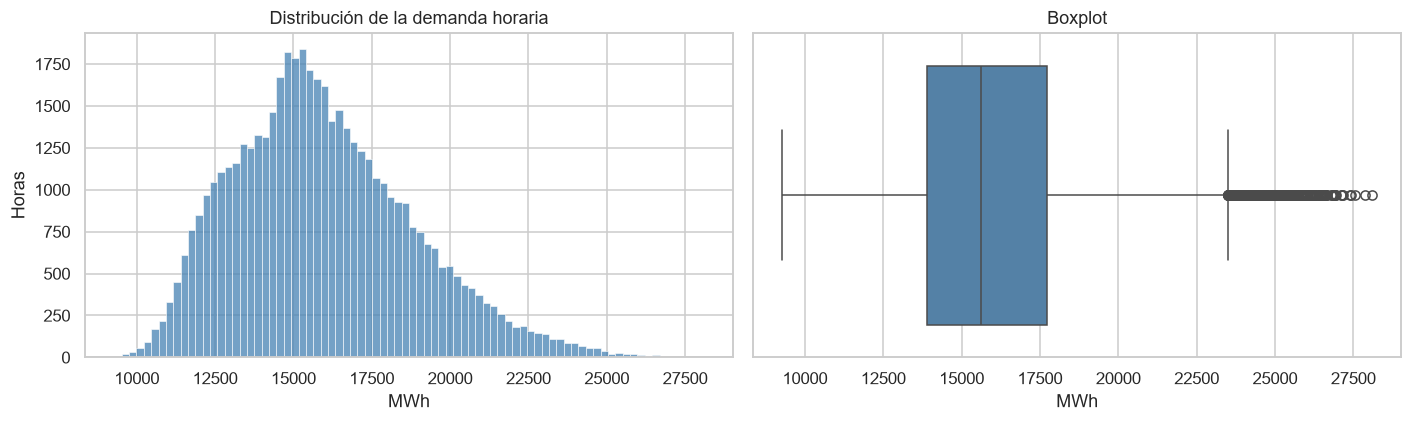

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["demanda_mwh"], bins=80, ax=ax[0], color="steelblue")
ax[0].set(title="Distribución de la demanda horaria", xlabel="MWh", ylabel="Horas")
sns.boxplot(x=df["demanda_mwh"], ax=ax[1], color="steelblue")
ax[1].set(title="Boxplot", xlabel="MWh")
guardar("distribucion_demanda")

La distribución es unimodal y algo asimétrica a la derecha (cola de picos de calor). Los puntos que el boxplot marca como "outliers" (por encima de ~23.500 MW, el límite Q3 + 1,5·IQR) son horas de olas de calor reales, no errores de medición: la sección 10 muestra que la demanda sube con la temperatura justamente en esos rangos. Conviene no eliminarlos, porque son las horas que más le importa acertar al operador.

## 4. Serie completa y tendencia interanual

Graficar 49.000 puntos horarios es ilegible, así que agregamos a **media diaria** y superponemos una **media móvil de 30 días** para ver la tendencia.

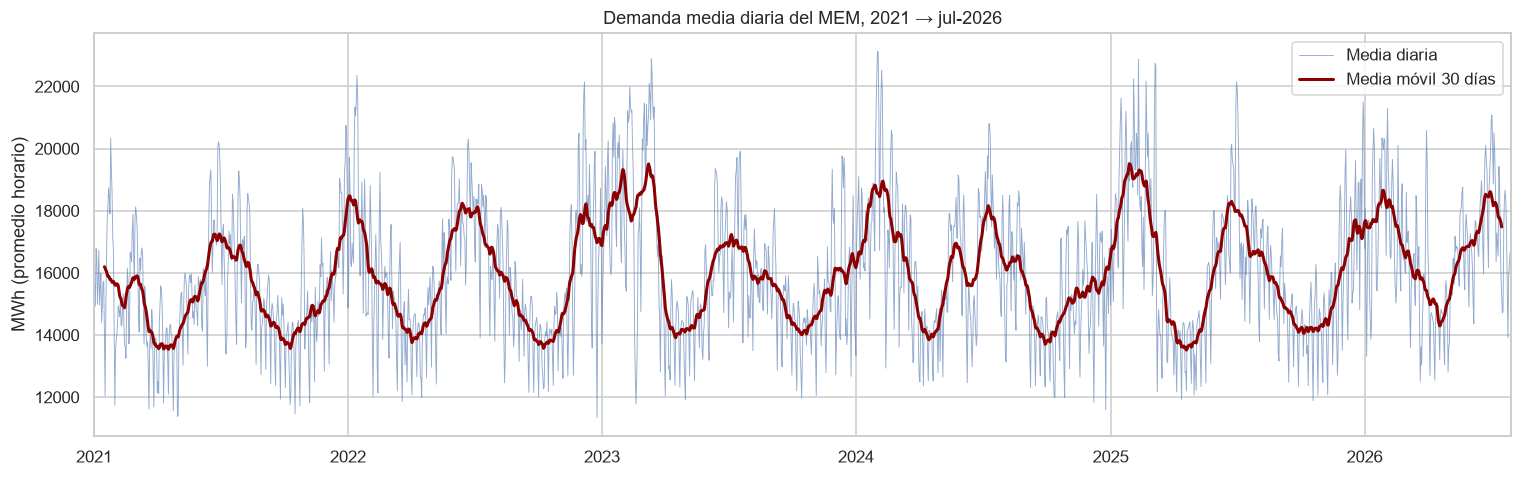

In [17]:
# resample("D") agrupa las 24 horas de cada día y calcula el promedio
diario = df.set_index("timestamp")["demanda_mwh"].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
diario.plot(ax=ax, lw=0.6, alpha=0.6, label="Media diaria")
diario.rolling(30, center=True).mean().plot(ax=ax, lw=2, color="darkred", label="Media móvil 30 días")
ax.set(title="Demanda media diaria del MEM, 2021 → jul-2026", ylabel="MWh (promedio horario)", xlabel="")
ax.legend()
guardar("serie_diaria")

In [18]:
anual = df.groupby(df.timestamp.dt.year)["demanda_mwh"].agg(media="mean", maximo="max", minimo="min").round(0)
anual["var_media_%"] = anual["media"].pct_change().mul(100).round(1)
anual

,media,maximo,minimo,var_media_%
timestamp,,,,
2021,15283.0,25092.0,9530.0,NaN
2022,15842.0,26213.0,9282.0,3.7
2023,16083.0,26918.0,9626.0,1.5
2024,15963.0,27433.0,9377.0,-0.7
2025,16125.0,28094.0,9638.0,1.0
2026,16764.0,25884.0,10428.0,4.0


Se ven dos cosas que el modelo va a tener que manejar:

- **Estacionalidad anual doble:** hay un pico en verano (ene–feb, aire acondicionado) y otro en invierno (jun–jul, calefacción). Es la relación en forma de U con la temperatura que se confirma en la sección 10.
- **Tendencia leve:** la media anual sube o baja unos pocos puntos porcentuales según el año (actividad económica, clima del año). No es un crecimiento sostenido fuerte, pero un modelo entrenado en 2021 y evaluado en 2026 tiene que tolerar ese corrimiento. *(Ojo: la fila de 2026 solo cubre ene–jul, no es comparable con años completos.)*

## 5. Estacionalidad anual: distribución por mes

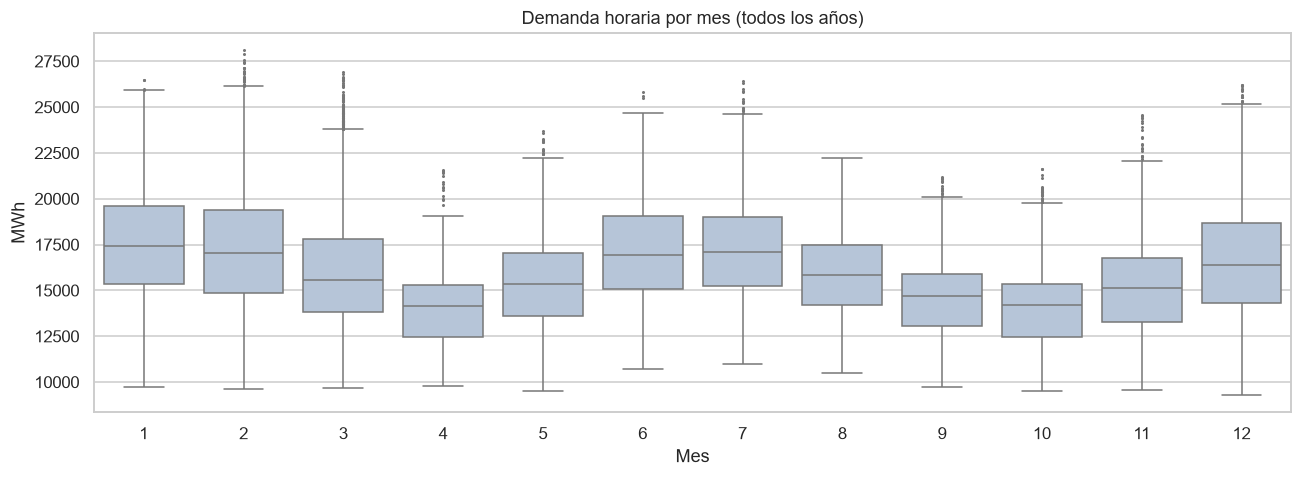

In [19]:
# columnas de calendario derivadas del timestamp, para agrupar
df["anio"] = df.timestamp.dt.year
df["mes"] = df.timestamp.dt.month
df["hora"] = df.timestamp.dt.hour
df["dia_semana"] = df.timestamp.dt.dayofweek  # 0 = lunes

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.boxplot(data=df, x="mes", y="demanda_mwh", ax=ax, color="lightsteelblue", fliersize=1)
ax.set(title="Demanda horaria por mes (todos los años)", xlabel="Mes", ylabel="MWh")
guardar("boxplot_mes")

La forma de "W" invertida confirma los dos picos: **enero–febrero** (calor) y **junio–julio** (frío). Los meses de transición (abril, octubre) son los más bajos y con menos dispersión: temperatura confortable, ni calefacción ni refrigeración. Enero es además el mes con la cola alta más larga; ahí están las horas récord.

## 6. Curva diaria típica

La "curva de carga" es la firma más importante de la demanda eléctrica. La vemos separando días hábiles de no hábiles, porque el uso comercial e industrial cambia completamente la forma.

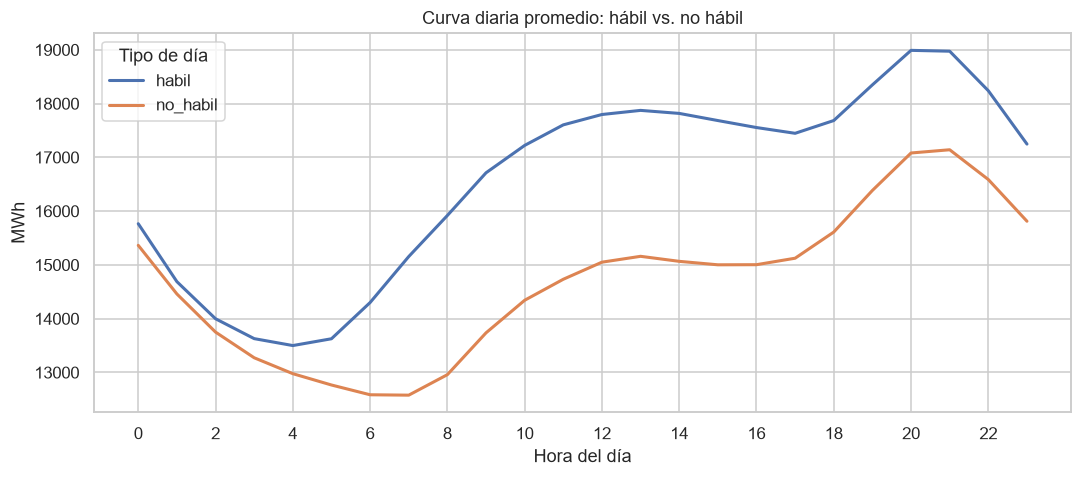

In [20]:
curva = df.groupby(["tipo_dia", "hora"])["demanda_mwh"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(10, 4.5))
curva.plot(ax=ax, lw=2)
ax.set(title="Curva diaria promedio: hábil vs. no hábil", xlabel="Hora del día", ylabel="MWh", xticks=range(0, 24, 2))
ax.legend(title="Tipo de día")
guardar("curva_diaria_tipo_dia")

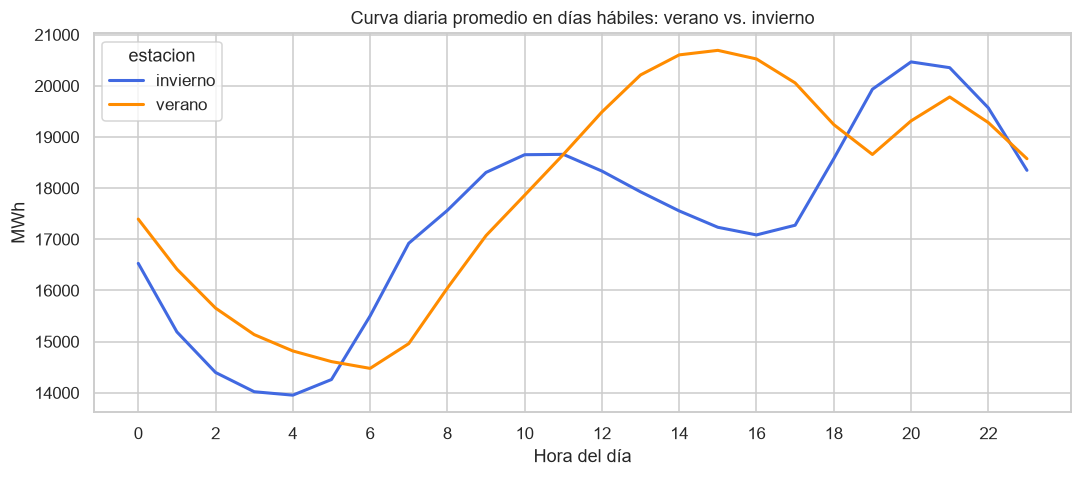

In [21]:
# la misma curva pero separando verano e invierno: cambia la hora del pico
estacion = df["mes"].map({12: "verano", 1: "verano", 2: "verano", 6: "invierno", 7: "invierno", 8: "invierno"})
sub = df[estacion.notna() & (df["tipo_dia"] == "habil")].assign(estacion=estacion)
curva_est = sub.groupby(["estacion", "hora"])["demanda_mwh"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(10, 4.5))
curva_est.plot(ax=ax, lw=2, color={"verano": "darkorange", "invierno": "royalblue"})
ax.set(title="Curva diaria promedio en días hábiles: verano vs. invierno", xlabel="Hora del día", ylabel="MWh", xticks=range(0, 24, 2))
guardar("curva_diaria_estacion")

Lecturas:

- **Valle nocturno** entre las 3 y las 6 h; **rampa de subida** fuerte de 6 a 10 h cuando arranca la actividad.
- En días hábiles la demanda se mantiene alta toda la jornada laboral; en no hábiles la curva es más chata y el nivel cae ~10–15 %.
- **El pico cambia de hora según la estación:** en verano el máximo es a la tarde (14–16 h, calor + oficinas + aire acondicionado); en invierno la curva tiene dos jorobas, una a media mañana (10–11 h) y el máximo a la noche (20–21 h, iluminación + calefacción al llegar a casa), con un valle a la siesta. Esto es una interacción *hora × estación* que un modelo lineal simple no captura y justifica probar Random Forest.

## 7. Perfil semanal

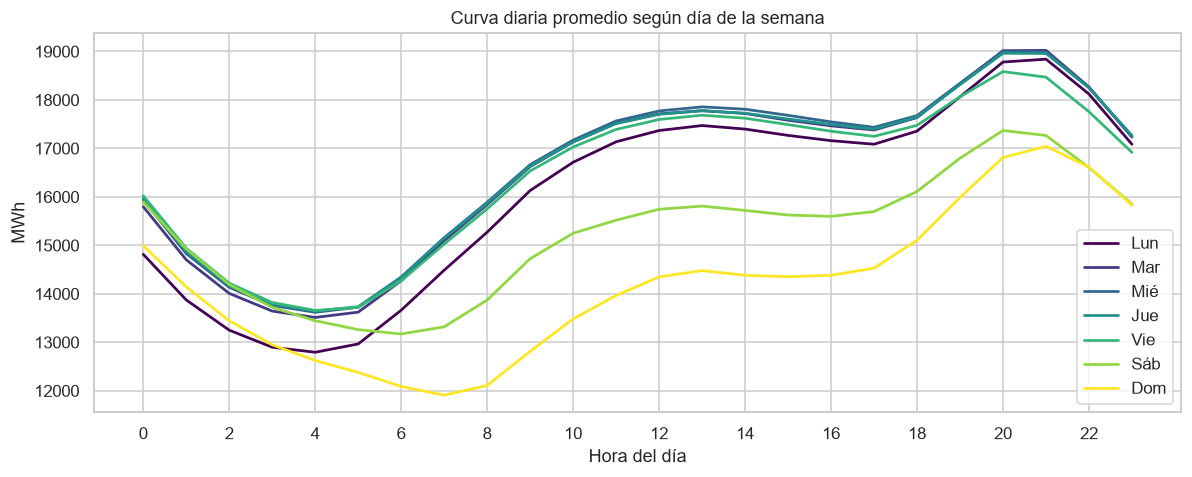

In [22]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
semanal = df.groupby(["dia_semana", "hora"])["demanda_mwh"].mean().unstack(0)
semanal.columns = dias

fig, ax = plt.subplots(figsize=(11, 4.5))
semanal.plot(ax=ax, lw=1.8, cmap="viridis")
ax.set(title="Curva diaria promedio según día de la semana", xlabel="Hora del día", ylabel="MWh", xticks=range(0, 24, 2))
guardar("perfil_semanal")

Martes a viernes son prácticamente indistinguibles. El lunes arranca algo más bajo en la madrugada (arrastra el domingo). El sábado es intermedio (comercio abierto a la mañana, industria parada) y el domingo es el día más bajo. Esto sugiere que como variable de calendario alcanza con algo como *hábil / sábado / domingo-feriado* más que con los 7 días por separado. El dataset regional ya trae exactamente esa clasificación de CAMMESA en 7 categorías (sección 10).

## 8. Mapa de calor hora × mes

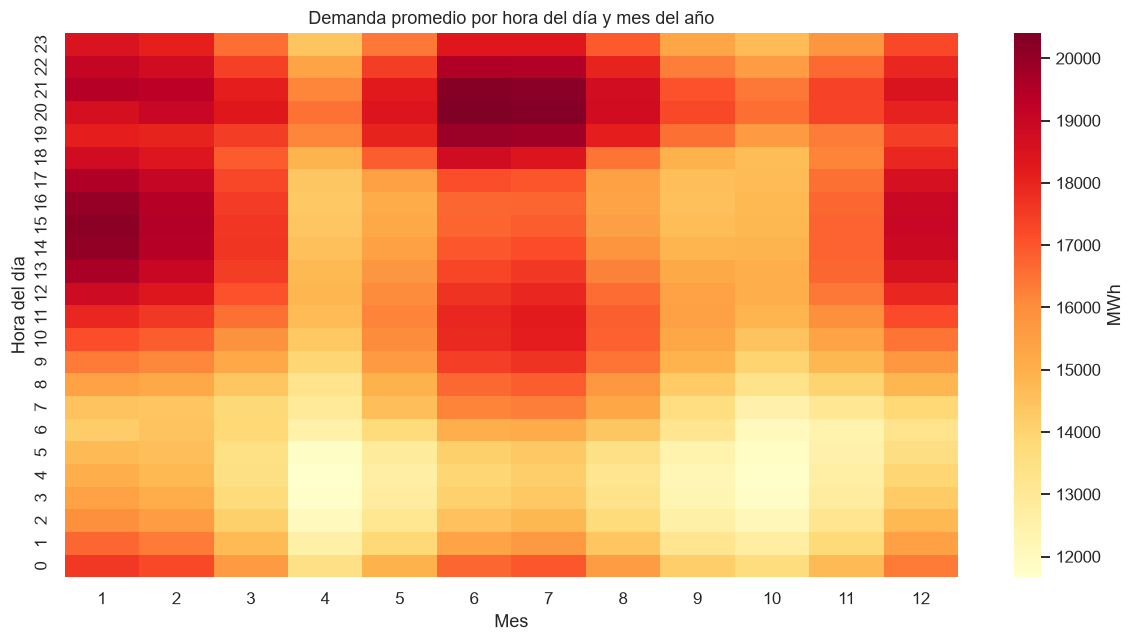

In [23]:
mapa = df.pivot_table(index="hora", columns="mes", values="demanda_mwh", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(mapa, cmap="YlOrRd", ax=ax, cbar_kws={"label": "MWh"})
ax.set(title="Demanda promedio por hora del día y mes del año", xlabel="Mes", ylabel="Hora del día")
ax.invert_yaxis()
guardar("heatmap_hora_mes")

El mapa resume todo lo anterior en una imagen: dos "manchas" calientes, una a la tarde de enero–febrero y otra a la noche de junio–julio, y una banda fría de madrugada todo el año. Cuando presentemos el modelo, esta es la figura que explica por qué hora y mes (o temperatura) son las variables que más pesan.

## 9. Las horas de mayor demanda

In [24]:
top = df.nlargest(10, "demanda_mwh")[["timestamp", "demanda_mwh", "tipo_dia"]].reset_index(drop=True)
top["demanda_mwh"] = top["demanda_mwh"].round(0)
top

,timestamp,demanda_mwh,tipo_dia
0,2025-02-10 15:00:00,28094.0,habil
1,2025-02-10 14:00:00,27884.0,habil
2,2025-02-10 16:00:00,27550.0,habil
3,2024-02-01 14:00:00,27433.0,habil
4,2024-02-01 15:00:00,27388.0,habil
5,2024-02-02 14:00:00,27158.0,habil
6,2024-02-02 15:00:00,27137.0,habil
7,2025-02-10 13:00:00,27118.0,habil
8,2025-02-10 17:00:00,26956.0,habil
9,2025-02-21 15:00:00,26923.0,habil


Todos los máximos históricos de la serie caen en tardes de días hábiles de verano. Son los eventos que más le importan al operador (riesgo de cortes) y también los más difíciles de pronosticar, porque dependen de olas de calor.

# Parte B — Dataset regional diario con clima

## 10. Demanda por región y temperatura (2017 → 2026)

### 10.1 Carga e inspección inicial

In [25]:
df_region = pd.read_csv(DATA / "dataset_demanda_por_region.csv", parse_dates=["Fecha"])

# veo las primeras filas del dataset para una inspección inicial
df_region.head()

,AÑO,MES,Fecha,Tipo día,zona,demanda,estacion_smn,TMAX,TMIN,TMEDIA,PRECIP,HELIOF,VTO_MDIR,VTO_MVEL,VEL_MED,PRE_EST,HUM_REL,NUB_TOT
0,2017,2017-01-01,2017-01-01,Domingo o Feriado,GRAN BS.AS.,6352.695208,AEROPARQUE AERO,34.0,28.0,30.5,NaN,7.6,14.0,54.0,7,1007.1,58.0,6
1,2017,2017-01-01,2017-01-02,Lunes habiles,GRAN BS.AS.,6617.863750,AEROPARQUE AERO,31.4,21.1,25.4,NaN,12.3,11.0,35.0,21,1011.4,68.0,1
2,2017,2017-01-01,2017-01-03,Martes Habiles,GRAN BS.AS.,6677.996167,AEROPARQUE AERO,28.4,22.3,25.3,6.0,3.0,34.0,50.0,13,1003.8,80.0,7
3,2017,2017-01-01,2017-01-04,Miercoles habiles,GRAN BS.AS.,6426.997625,AEROPARQUE AERO,30.8,23.0,26.0,NaN,8.3,23.0,17.0,8,1004.1,70.0,5
4,2017,2017-01-01,2017-01-05,Jueves Habiles,GRAN BS.AS.,5873.950750,AEROPARQUE AERO,28.0,19.7,25.4,NaN,12.0,11.0,33.0,10,1011.5,35.0,0


In [26]:
# veo cantidad de filas y de columnas del dataset
df_region.shape

(31212, 18)

In [27]:
# veo los tipos de datos de cada columna del dataset
df_region.dtypes

AÑO                      int64
MES                        str
Fecha           datetime64[us]
Tipo día                   str
zona                       str
demanda                float64
estacion_smn               str
TMAX                   float64
TMIN                   float64
TMEDIA                 float64
PRECIP                 float64
HELIOF                 float64
VTO_MDIR               float64
VTO_MVEL               float64
VEL_MED                  int64
PRE_EST                float64
HUM_REL                float64
NUB_TOT                  int64
dtype: object

A primera vista hay tres cosas para atender:

- La columna `MES` no tiene el tipo que corresponde: es texto con la fecha del primer día del mes (`2017-01-01`) en lugar del número de mes.
- Los nombres de las columnas no siguen una nomenclatura común: mezclan mayúsculas y minúsculas, y tienen tildes y espacios (`AÑO`, `Tipo día`, `zona`).
- Hay valores faltantes en algunas variables climáticas.

In [28]:
# veo si hay duplicados de la clave del dataset: no puede haber dos filas para el mismo día y la misma región
df_region.duplicated(subset=["Fecha", "zona"]).sum()

np.int64(0)

In [29]:
# chequeo que cada región tenga todos los días del período, sin huecos
dias_esperados = (df_region.Fecha.max() - df_region.Fecha.min()).days + 1
print(f"Rango: {df_region.Fecha.min().date()} -> {df_region.Fecha.max().date()} ({dias_esperados:,} días)")
df_region.groupby("zona")["Fecha"].nunique().rename("dias_presentes").to_frame()

Rango: 2017-01-01 -> 2026-06-30 (3,468 días)


,dias_presentes
zona,
BUENOS AIRES,3468
CENTRO,3468
COMAHUE,3468
CUYO,3468
GRAN BS.AS.,3468
LITORAL,3468
NORESTE,3468
NOROESTE,3468
PATAGONICA,3468


In [30]:
# vemos los tipos de día que hay
df_region["Tipo día"].unique()

<ArrowStringArray>
[     'Domingo o Feriado',          'Lunes habiles',         'Martes Habiles',
      'Miercoles habiles',         'Jueves Habiles',        'Viernes habiles',
 'Sabado o Semilaborable']
Length: 7, dtype: str

In [31]:
# contabilizo los nulos por columna
df_region.isna().sum()

AÑO                 0
MES                 0
Fecha               0
Tipo día            0
zona                0
demanda             0
estacion_smn        0
TMAX               95
TMIN               11
TMEDIA              0
PRECIP          22679
HELIOF           3328
VTO_MDIR            2
VTO_MVEL            2
VEL_MED             0
PRE_EST             0
HUM_REL             1
NUB_TOT             0
dtype: int64

Los faltantes están solo en variables climáticas (`PRECIP`, `HELIOF`, algunos `TMAX`/`TMIN` y casos aislados de viento y humedad); la demanda no tiene ninguno. En la sección 10.6 se analizan por región.

Sobre `PRECIP`: según el diccionario de datos del SMN, una celda vacía correspondería a un día sin lluvia. Si se confirma con la documentación, esos vacíos pasarían a 0 mm en el script que construye el dataset. Mientras tanto se dejan como faltantes.

In [32]:
# veo un resumen estadístico de la demanda por zona
df_region.groupby("zona")["demanda"].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
zona,,,,,,,,
BUENOS AIRES,3468.0,1830.0,213.0,923.0,1687.0,1826.0,1964.0,2507.0
CENTRO,3468.0,1361.0,213.0,818.0,1220.0,1337.0,1485.0,2277.0
COMAHUE,3468.0,581.0,59.0,257.0,539.0,576.0,611.0,856.0
CUYO,3468.0,942.0,136.0,655.0,848.0,913.0,1008.0,1510.0
GRAN BS.AS.,3468.0,5806.0,1023.0,3765.0,5066.0,5594.0,6505.0,9367.0
LITORAL,3468.0,1872.0,318.0,1197.0,1672.0,1822.0,2044.0,3167.0
NORESTE,3468.0,1147.0,287.0,596.0,922.0,1048.0,1341.0,2100.0
NOROESTE,3468.0,1289.0,237.0,664.0,1115.0,1230.0,1426.0,2231.0
PATAGONICA,3468.0,661.0,94.0,399.0,601.0,646.0,697.0,989.0


Las regiones tienen escalas muy distintas: GBA promedia ~5.800 MW y Comahue ~580 MW, diez veces menos. Por eso, para comparar regiones entre sí conviene mirar participaciones (%) o darle a cada una su propia escala, como se hace en los gráficos siguientes.

Estructura: una fila por **día y región**. 9 regiones × 3.468 días = 31.212 filas, sin duplicados ni días faltantes.

- `demanda`: demanda media del día en la región (MW).
- `Tipo día`: clasificación de CAMMESA en 7 categorías (lunes hábil, …, sábado o semilaborable, domingo o feriado).
- `estacion_smn`: estación representativa seleccionada para esa región (siempre la misma, ver README). Es una **proxy** del clima de la región: regiones extensas como Patagonia o NOA abarcan climas muy distintos y una sola estación no los representa a todos. Es una limitación espacial del dataset.
- Clima diario de esa estación: temperaturas (`TMAX`, `TMIN`, `TMEDIA`, °C), precipitación (`PRECIP`), heliofanía (`HELIOF`, horas de sol), viento (`VTO_MDIR` en decenas de grados, con 99 = calma o variable; `VTO_MVEL`, `VEL_MED`, km/h), presión a la altura de la estación (`PRE_EST`, hPa), humedad (`HUM_REL`, %) y nubosidad (`NUB_TOT`, octavos).

#### Transformaciones de formato

Se corrigen los dos problemas de formato detectados. No se imputan faltantes: cómo tratarlos es una decisión de la etapa de modelado (hacerlo acá, con estadísticos de todo el período, filtraría información del futuro al entrenamiento).

In [33]:
# estandarizo el nombre de las columnas para que no tengan tildes ni espacios y sigan una misma nomenclatura
df_region = df_region.rename(columns={
    "AÑO": "ANIO",
    "Fecha": "FECHA",
    "Tipo día": "TIPO_DIA",
    "zona": "ZONA",
    "demanda": "DEMANDA",
    "estacion_smn": "ESTACION_SMN",
})

df_region.columns

Index(['ANIO', 'MES', 'FECHA', 'TIPO_DIA', 'ZONA', 'DEMANDA', 'ESTACION_SMN',
       'TMAX', 'TMIN', 'TMEDIA', 'PRECIP', 'HELIOF', 'VTO_MDIR', 'VTO_MVEL',
       'VEL_MED', 'PRE_EST', 'HUM_REL', 'NUB_TOT'],
      dtype='str')

In [34]:
# elimino la columna MES (texto) y la vuelvo a crear como número de mes a partir de FECHA
df_region = df_region.drop(columns="MES")
df_region["MES"] = df_region["FECHA"].dt.month

df_region[["ANIO", "MES", "FECHA", "TIPO_DIA", "ZONA", "DEMANDA"]].head()

,ANIO,MES,FECHA,TIPO_DIA,ZONA,DEMANDA
0,2017,1,2017-01-01,Domingo o Feriado,GRAN BS.AS.,6352.695208
1,2017,1,2017-01-02,Lunes habiles,GRAN BS.AS.,6617.863750
2,2017,1,2017-01-03,Martes Habiles,GRAN BS.AS.,6677.996167
3,2017,1,2017-01-04,Miercoles habiles,GRAN BS.AS.,6426.997625
4,2017,1,2017-01-05,Jueves Habiles,GRAN BS.AS.,5873.950750


### 10.2 Validación cruzada contra la serie horaria

Los dos datasets vienen de planillas distintas de CAMMESA. Si están bien armados, la suma de las 9 regiones en un día tiene que dar lo mismo que el promedio de las 24 horas de ese día en la serie horaria.

In [35]:
total_region = df_region.groupby("FECHA")["DEMANDA"].sum().rename("suma_regiones")
comparacion = pd.concat([diario.rename("serie_horaria"), total_region], axis=1, join="inner")
comparacion["dif_%"] = (comparacion.suma_regiones - comparacion.serie_horaria) / comparacion.serie_horaria * 100

print(f"Días en común: {len(comparacion):,}")
print(f"Diferencia media: {comparacion['dif_%'].mean():.3f} %  |  máxima absoluta: {comparacion['dif_%'].abs().max():.2f} %")
print(f"Correlación: {comparacion.serie_horaria.corr(comparacion.suma_regiones):.4f}")

Días en común: 2,007
Diferencia media: 0.001 %  |  máxima absoluta: 0.38 %
Correlación: 1.0000


Coinciden en los más de 2.000 días que comparten (diferencia máxima menor a 0,5 %). Las dos fuentes son consistentes, así que lo que aprendamos del dataset regional vale para la serie que vamos a modelar.

### 10.3 Participación y estacionalidad de cada región

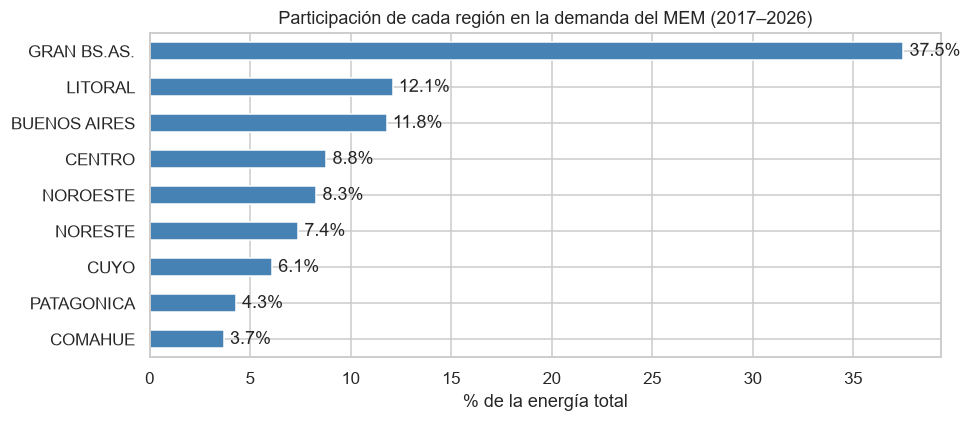

In [36]:
participacion = df_region.groupby("ZONA")["DEMANDA"].sum()
participacion = (participacion / participacion.sum() * 100).sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
participacion.plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set(title="Participación de cada región en la demanda del MEM (2017–2026)", xlabel="% de la energía total", ylabel="")
for i, v in enumerate(participacion):
    ax.text(v + 0.3, i, f"{v}%", va="center")
guardar("participacion_regional")

Gran Buenos Aires + Litoral + Buenos Aires concentran el 61 % de la demanda nacional (GBA sola, 37,5 %), así que el total país está fuertemente influido por el clima de la región pampeana.

**Estacionalidad anual de cada región.** Cada panel tiene su propia escala, y cada línea es un año (demanda media mensual). Si las líneas de un panel tienen la misma forma, la región repite su patrón estacional año a año.

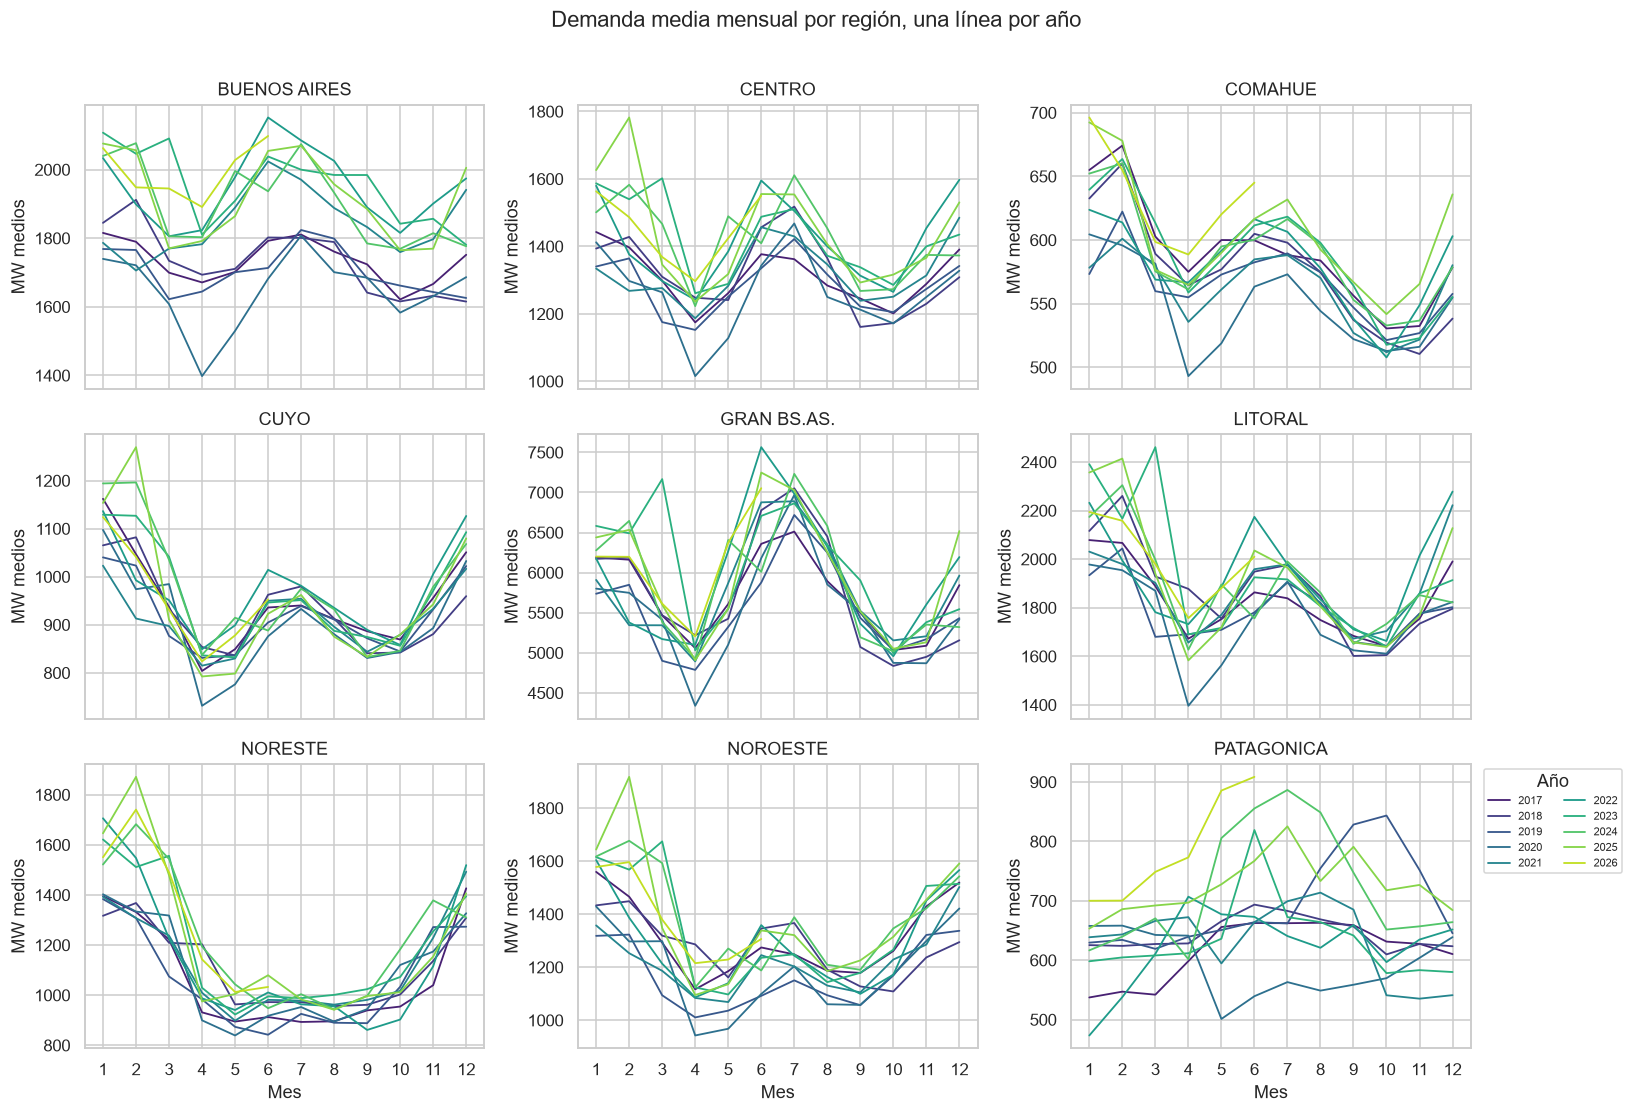

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
mensual = df_region.groupby(["ZONA", "ANIO", "MES"])["DEMANDA"].mean().reset_index()
mensual["ANIO"] = mensual["ANIO"].astype(str)  # como categoría, para que la leyenda muestre todos los años
for ax, (zona, datos) in zip(axes.flat, mensual.groupby("ZONA")):
    sns.lineplot(data=datos, x="MES", y="DEMANDA", hue="ANIO", palette="viridis", lw=1.2, ax=ax, legend=(zona == "PATAGONICA"))
    ax.set(title=zona, xlabel="Mes", ylabel="MW medios", xticks=range(1, 13))
axes.flat[-1].legend(title="Año", fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Demanda media mensual por región, una línea por año", y=1.01)
guardar("demanda_mensual_por_region")

En la mayoría de las regiones la forma se repite todos los años, con dos patrones según el clima:

- **Picos en verano e invierno** (GBA, Buenos Aires, Centro, Litoral, Comahue): demanda alta en enero–febrero y en junio–julio, y mínimos en abril y octubre.
- **Pico principal en verano y uno menor en invierno** (Cuyo, NOA), y **casi solo verano** en NEA, donde la demanda de enero–febrero supera en ~30 % a su media anual.

**Patagonia es la excepción:** tiene saltos de nivel que no siguen el calendario (por ejemplo, +200 MW entre agosto y noviembre de 2019, o el salto del invierno de 2024), típicos de grandes cargas industriales que se prenden o se apagan. También se ve en varias regiones la caída de abril–mayo de 2020 por la cuarentena, y un escalón de ~10 % en la región Buenos Aires desde 2021.

### 10.4 Forma de la curva diaria por región

El dataset regional es diario, así que para ver la forma de la curva *dentro* del día usamos la planilla horaria por regiones de CAMMESA (2021–2023). Normalizamos cada región por su propia media para comparar formas y no tamaños.

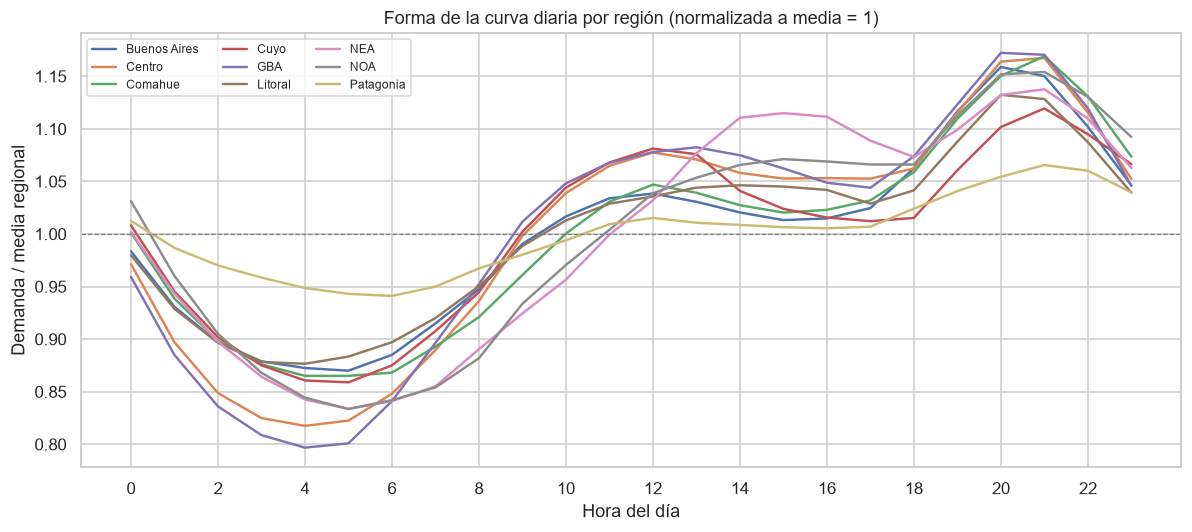

In [38]:
reg = pd.read_csv(DATA / "demanda_horaria_regiones_2021_2023.csv", parse_dates=["timestamp"])
reg["hora"] = reg.timestamp.dt.hour
curva_reg = reg.groupby(["region", "hora"])["demanda_mwh"].mean().unstack(0)
curva_reg_norm = curva_reg / curva_reg.mean()

fig, ax = plt.subplots(figsize=(11, 5))
curva_reg_norm.plot(ax=ax, lw=1.6)
ax.axhline(1, color="gray", ls="--", lw=0.8)
ax.set(title="Forma de la curva diaria por región (normalizada a media = 1)", xlabel="Hora del día", ylabel="Demanda / media regional", xticks=range(0, 24, 2))
ax.legend(ncol=3, fontsize=8)
guardar("curva_diaria_regional")

Patagonia tiene la curva más chata de todas (oscila apenas ±6 % alrededor de su media): allí pesa la industria petrolera y minera, que consume parejo las 24 h. En el otro extremo, GBA tiene el valle nocturno más profundo (−20 %) y el pico nocturno más alto: perfil residencial puro. NEA se distingue porque su pico es a la tarde (14–16 h), por el peso del aire acondicionado en el clima subtropical.

### 10.5 Relación entre demanda y temperatura

Es la hipótesis central del proyecto: la demanda tiene forma de **U** respecto de la temperatura (sube con el calor por el aire acondicionado y con el frío por la calefacción). Lo miramos en tres regiones con climas bien distintos, usando solo días hábiles para que el fin de semana no mezcle niveles.

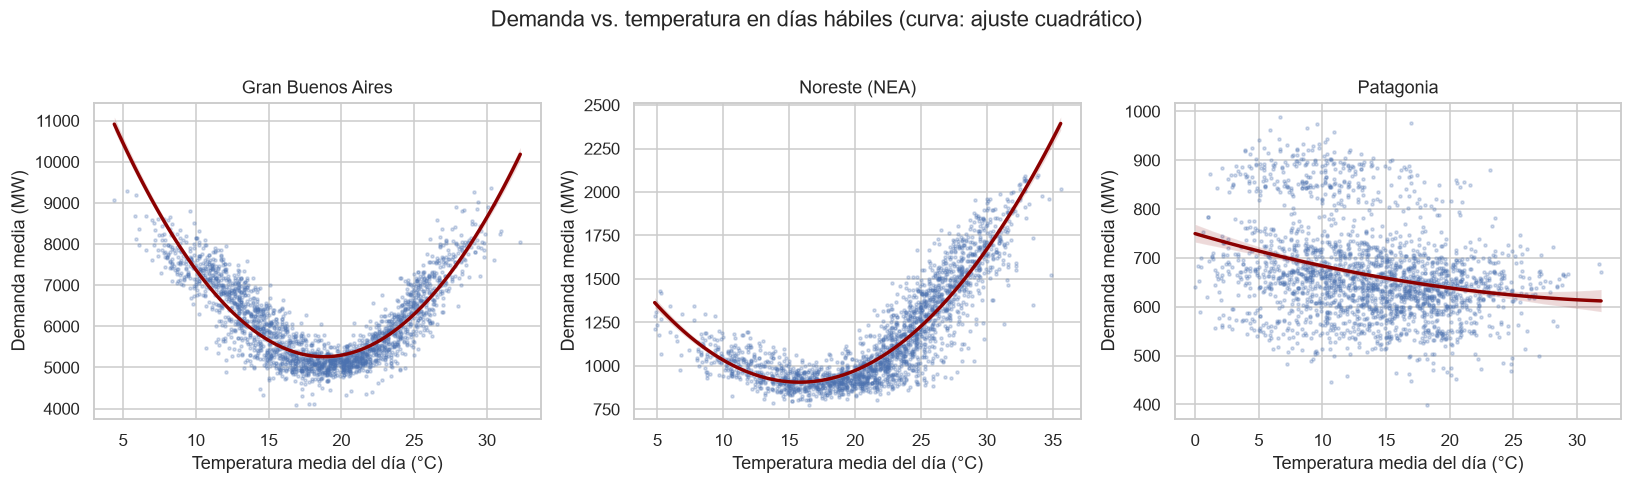

In [39]:
regiones = {"GRAN BS.AS.": "Gran Buenos Aires", "NORESTE": "Noreste (NEA)", "PATAGONICA": "Patagonia"}
habiles = df_region[df_region["TIPO_DIA"].str.contains("abil")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (zona, nombre) in zip(axes, regiones.items()):
    sub = habiles[habiles.ZONA == zona]
    sns.regplot(data=sub, x="TMEDIA", y="DEMANDA", order=2, ax=ax,
                scatter_kws={"s": 4, "alpha": 0.25}, line_kws={"color": "darkred"})
    ax.set(title=nombre, xlabel="Temperatura media del día (°C)", ylabel="Demanda media (MW)")
fig.suptitle("Demanda vs. temperatura en días hábiles (curva: ajuste cuadrático)", y=1.02)
guardar("demanda_vs_temperatura")

In [40]:
# ajuste cuadrático demanda = a·T² + b·T + c en días hábiles, por región
# R²: qué proporción de la variación de la demanda explica la curva
# vértice: temperatura donde la curva tiene su mínimo (-b / 2a); solo es una U si a > 0 y el vértice cae dentro del rango observado
filas = []
for zona, nombre in regiones.items():
    sub = habiles[habiles.ZONA == zona]
    a, b, c = np.polyfit(sub["TMEDIA"], sub["DEMANDA"], 2)
    pred = np.polyval([a, b, c], sub["TMEDIA"])
    r2 = 1 - ((sub["DEMANDA"] - pred) ** 2).sum() / ((sub["DEMANDA"] - sub["DEMANDA"].mean()) ** 2).sum()
    vertice = -b / (2 * a)
    es_u = a > 0 and sub["TMEDIA"].min() <= vertice <= sub["TMEDIA"].max()
    filas.append({"región": nombre, "R² cuadrático": round(r2, 2), "vértice (°C)": round(vertice, 1),
                  "curva en U": "sí" if es_u else "no",
                  "T mín observada": sub["TMEDIA"].min(), "T máx observada": sub["TMEDIA"].max()})
pd.DataFrame(filas).set_index("región")

,R² cuadrático,vértice (°C),curva en U,T mín observada,T máx observada
región,,,,,
Gran Buenos Aires,0.77,18.8,sí,4.4,32.3
Noreste (NEA),0.82,15.8,sí,4.8,35.6
Patagonia,0.08,36.7,no,0.0,31.9


In [41]:
# la correlación lineal subestima una relación en U: sube de un lado y baja del otro, y se compensa
corr = df_region.groupby("ZONA")[["DEMANDA", "TMEDIA"]].corr().xs("TMEDIA", level=1)["DEMANDA"]
corr.sort_values().round(2).rename("corr_lineal_demanda_TMEDIA").to_frame()

,corr_lineal_demanda_TMEDIA
ZONA,
PATAGONICA,-0.28
GRAN BS.AS.,-0.18
BUENOS AIRES,-0.04
CENTRO,0.08
COMAHUE,0.20
LITORAL,0.32
CUYO,0.48
NOROESTE,0.53
NORESTE,0.72


Lecturas:

- **GBA muestra la U completa:** según la tabla, el vértice está cerca de los 19 °C de temperatura media en Aeroparque y la demanda sube hacia ambos extremos. El ajuste cuadrático explica ~77 % de la variación diaria de la demanda de días hábiles. Su correlación lineal es casi nula, pero la relación es fuerte. Es el ejemplo de por qué no alcanza con mirar la correlación de Pearson, y un argumento para modelos que capturen no linealidades (Random Forest) o para crear variables como *grados-día de calefacción* y *de refrigeración*.
- **NEA** también tiene forma de U, pero la rama de calor domina (clima subtropical: hay muchos más días calurosos que fríos y el aire acondicionado pesa mucho). Por eso su correlación lineal es alta y positiva.
- **Patagonia** no muestra una U: solo una leve suba con el frío y mucha dispersión (R² menor a 0,10, y el vértice cae fuera del rango de temperaturas observado): su demanda depende más de la actividad industrial (petróleo, minería) que del clima, coherente con su curva diaria chata de la sección 10.4.

Como el total país está dominado por GBA y la región pampeana, esperamos que la temperatura de esa zona sea la variable climática más útil para el modelo. Ojo: estas relaciones se miden con la temperatura de **una estación por región**, que es una proxy; parte de la dispersión de los gráficos puede deberse a que esa estación no representa todo el territorio de la región.

### 10.6 Calidad de las variables climáticas

Antes de usar el clima como variable del modelo hay que chequear que no falten datos y que los valores sean físicamente posibles.

En la primera versión de este dataset las variables climáticas **cambiaban de escala de golpe en 2021** (la presión pasaba de ~985 a ~180 hPa, el viento de ~11 a ~850, la humedad de ~65 % a ~10 %). La causa estaba en el **parser del archivo del SMN desde 2021** (`.lst`): ese archivo separa las columnas con tabuladores y marca un dato faltante como un campo vacío entre dos tabuladores. El código original lo separaba por "cualquier espacio", lo que eliminaba esos campos vacíos y corría todas las columnas siguientes un lugar. El script `src/construir_dataset_regional.py` lo lee respetando los tabuladores. Las celdas siguientes muestran que las columnas quedaron alineadas.

In [42]:
# nulos por variable y región: cada región usa una sola estación, así que se ven los faltantes reales
clima = ["TMAX", "TMIN", "TMEDIA", "PRECIP", "HELIOF", "VTO_MDIR", "VTO_MVEL", "VEL_MED", "PRE_EST", "HUM_REL", "NUB_TOT"]
df_region.groupby("ZONA")[clima].apply(lambda g: g.isna().sum())

,TMAX,TMIN,TMEDIA,PRECIP,HELIOF,VTO_MDIR,VTO_MVEL,VEL_MED,PRE_EST,HUM_REL,NUB_TOT
ZONA,,,,,,,,,,,
BUENOS AIRES,0,0,0,2357,0,0,0,0,0,0,0
CENTRO,0,0,0,2446,727,0,0,0,0,0,0
COMAHUE,11,5,0,2875,521,0,0,0,0,0,0
CUYO,84,6,0,2916,218,1,1,0,0,0,0
GRAN BS.AS.,0,0,0,2354,363,0,0,0,0,0,0
LITORAL,0,0,0,2420,826,1,1,0,0,0,0
NORESTE,0,0,0,2448,234,0,0,0,0,0,0
NOROESTE,0,0,0,2345,439,0,0,0,0,1,0
PATAGONICA,0,0,0,2518,0,0,0,0,0,0,0


In [43]:
# valores imposibles: el día tiene 24 h de sol como máximo, la humedad relativa va de 0 a 100 %
# y la temperatura máxima no puede ser menor a la mínima
print("HELIOF fuera de 0-24 h:  ", (~df_region.HELIOF.dropna().between(0, 24)).sum())
print("HUM_REL fuera de 0-100 %:", (~df_region.HUM_REL.dropna().between(0, 100)).sum())
print("TMAX < TMIN:             ", (df_region.TMAX < df_region.TMIN).sum())

HELIOF fuera de 0-24 h:   0
HUM_REL fuera de 0-100 %: 0
TMAX < TMIN:              0


In [44]:
# mediana de cada variable antes y después de 2021 (el corte entre los dos archivos del SMN):
# si las columnas estuvieran corridas, las medianas cambiarían de escala
periodo = np.where(df_region.FECHA.dt.year >= 2021, "2021-2026", "2017-2020")
medianas = df_region.groupby(periodo)[clima].median().T.round(1)
medianas["diferencia"] = (medianas["2021-2026"] - medianas["2017-2020"]).round(1)
medianas

,2017-2020,2021-2026,diferencia
TMAX,24.2,24.4,0.2
TMIN,12.4,12.4,0.0
TMEDIA,18.0,18.0,0.0
PRECIP,1.0,1.0,0.0
HELIOF,8.2,8.2,0.0
VTO_MDIR,18.0,18.0,0.0
VTO_MVEL,31.0,33.0,2.0
VEL_MED,11.0,10.0,-1.0
PRE_EST,1000.7,1000.9,0.2
HUM_REL,67.0,66.0,-1.0


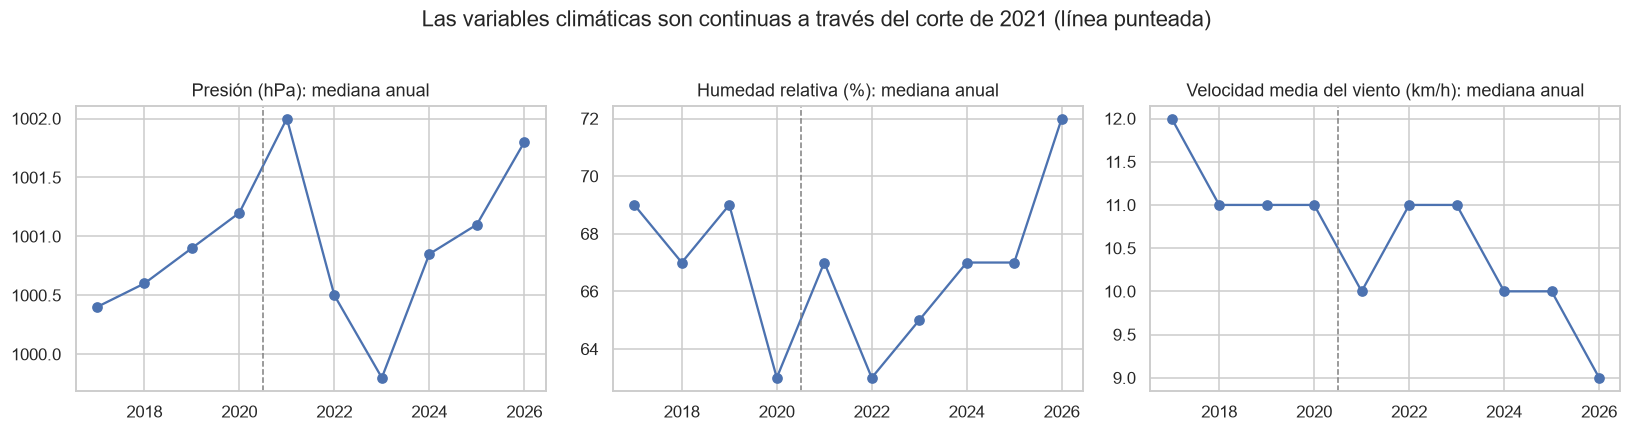

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
anual_clima = df_region.groupby(df_region.FECHA.dt.year)[clima].median()
for ax, (col, titulo) in zip(axes, [("PRE_EST", "Presión (hPa)"), ("HUM_REL", "Humedad relativa (%)"), ("VEL_MED", "Velocidad media del viento (km/h)")]):
    anual_clima[col].plot(ax=ax, marker="o")
    ax.axvline(2020.5, color="gray", ls="--", lw=1)
    ax.set(title=f"{titulo}: mediana anual", xlabel="")
fig.suptitle("Las variables climáticas son continuas a través del corte de 2021 (línea punteada)", y=1.03)
guardar("clima_alineado_2021")

**Resultado:** con el parser corregido, las medianas de 2017–2020 y 2021–2026 prácticamente coinciden (presión ~1.000 hPa, humedad ~66 %, viento ~10–11 km/h, heliofanía ~8 h) y no queda ningún valor imposible.

Hay que distinguir dos cosas:

- **Columnas alineadas:** las 11 variables climáticas quedaron en su lugar y son consistentes en todo el período. Esto es lo que corrigió el parser.
- **Columnas listas para modelar:** es otra cuestión, y depende de los faltantes:
  - `TMEDIA`, `HUM_REL`, `PRE_EST`, `VEL_MED` y `NUB_TOT` están completas o casi (1 nulo como máximo).
  - `TMAX`, `TMIN` y `HELIOF` tienen faltantes que habría que tratar (imputar o excluir filas) antes de usarlas.
  - `PRECIP` **no está lista**: tiene ~73 % de celdas vacías de significado ambiguo.
  - `VTO_MDIR` es una dirección codificada (1–36, con 99 para calma), no una magnitud: no se puede usar como número tal cual.

Nulos que quedan (se dejan como NaN, no se imputan):

- **`PRECIP` (~73 %):** el SMN deja la celda vacía la mayoría de los días, y además registra ceros explícitos otros días. No se puede saber con certeza si el vacío significa "no llovió" o "no se midió". Hasta resolverlo, la precipitación no es confiable como variable.
- **`HELIOF` (~11 %):** faltantes reales de algunas estaciones (Rosario, Córdoba y Neuquén son las que más tienen).
- **`TMAX` / `TMIN`:** menos de 100 días en total, casi todos en Mendoza. `TMEDIA`, la variable climática principal, no tiene ningún nulo.

## 11. Hallazgos y decisiones para la siguiente etapa

**Sobre los datos**

- Serie horaria (objetivo): 48.912 horas consecutivas (2021-01-01 → 2026-07-31), sin huecos, duplicados, nulos ni ceros en la variable objetivo.
- Dataset regional diario: 9 regiones × 3.468 días (2017-01-01 → 2026-06-30), completo. Su demanda coincide con la serie horaria (diferencia < 0,5 %). En el EDA se estandarizaron los nombres de columnas (sin tildes ni espacios) y `MES` pasó a número de mes.
- Los valores extremos de demanda (> ~23.500 MW) son olas de calor reales; se conservan.
- El clima sale de una estación representativa seleccionada por región: es una proxy con una limitación espacial (una estación no representa todo el territorio de la región). El quiebre de 2021 en humedad, heliofanía, precipitación, viento y presión era un error del parser del archivo `.lst` y quedó corregido: las 11 variables quedaron alineadas y son continuas en el período. Alineadas no significa listas para modelar: `PRECIP` no lo está y `HELIOF`, `TMAX` y `TMIN` tienen faltantes.
- `TMEDIA` no tiene nulos. `PRECIP` tiene ~73 % de celdas vacías de significado ambiguo y `HELIOF` ~11 % de faltantes; se dejan como NaN.

**Sobre la estructura de la demanda**

- Tres estacionalidades superpuestas: diaria (valle 3–6 h, pico tarde o noche), semanal (hábil > sábado > domingo) y anual (picos en verano e invierno).
- La hora del pico depende de la estación → interacción hora × temporada, argumento para modelos no lineales.
- Relación en U con la temperatura, clara en GBA (mínimo ~19 °C) y NEA; la correlación lineal no la captura. En Patagonia la temperatura casi no explica la demanda.
- A nivel regional el patrón estacional se repite año a año (picos en verano e invierno en la zona pampeana, predominio del verano en el norte), salvo en Patagonia, donde dominan saltos de nivel industriales.
- Tendencia interanual leve pero presente; hay que tenerla en cuenta al hacer el split temporal.

**Decisiones tomadas**

- Variable objetivo: demanda horaria del total país (MEM), 2021 → jul-2026.
- El dataset regional diario se usa para el EDA regional. No es la fuente de temperatura del modelo horario. Se construye con `src/construir_dataset_regional.py`, que valida el resultado y se detiene si algo no cierra.

**Pendiente para la próxima etapa**

- Confirmar con el diccionario de datos del SMN que una celda vacía de `PRECIP` significa 0 mm y, si es así, aplicarlo en `src/construir_dataset_regional.py`. Decidir cómo tratar los faltantes de `HELIOF`, `TMAX` y `TMIN` en la etapa de modelado.
- Conseguir **temperatura horaria** histórica para el modelo (no repetir la `TMEDIA` diaria en las 24 horas) y definir de qué región(es) tomarla (GBA sola o promedio ponderado por participación).
- Construir variables de calendario (hora, día de semana, mes, estación, tipo de día) y derivadas de temperatura (grados-día de calefacción y refrigeración).
- La normalización/estandarización de variables se hace dentro del pipeline de cada modelo, ajustada solo con el set de entrenamiento, para evitar *data leakage*.